<h1> Individual Planning Report - DSCI 100 - Jacob Tan</h1>

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
players <- read_csv("https://raw.githubusercontent.com/daisfasl/DSCI100-Individual-Project-Report/refs/heads/main/players.csv")
sessions <- read_csv("https://raw.githubusercontent.com/daisfasl/DSCI100-Individual-Project-Report/refs/heads/main/sessions.csv")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


<h2> 1) Data Description </h2>

For the project, we utilize two datasets collected from a Minecraft research server: "players.csv", containing individual player data, and "sessions.csv" which contains individual play session data.

<h3> players.csv </h3>

- Per-player observations totalling 196 individual observations (196 rows)
- 7 measured variables (7 columns)
  1) experience (chr): Categorical variable reporting a player's experience (e.g. "Beginner", "Amateur", "Regular", "Veteran", "Pro").
  2) subscribe (igl): Boolean variable indicating whether or not a player is subscribed to a gaming newsletter.
  3) hashedEmail (chr): Categorical variable indicating each player's unique, recognizable code.
  4) played_hours (dbl): Numerical variable representing each player's total # of hours played.
  5) name (chr): Categorical variable for the player's name in the server.
  6) gender (chr): Categorical variable for the player's gender.
  7) Age (dbl): Numerical variable for the player's age.


<h3> sessions.csv </h3>

- Per-session observations totalling 1535 observations (1535 rows)
- 5 measured variables (5 columns)
  1) hashedEmail (chr): Categorical variable indicating each player's unique, recognizable code.
  2) start_time (chr): Categorical variable indicating the start time of each session.
  3) end_time (chr): Categorical variable indicating the end time of each session.
  4) original_start_time (dbl): Numerical variable indicating the start time of each session, each stored as a Unix time identifier.
  5) original_end_time (dbl): Numerical variable indicating the end time of each session, each stored as a Unix time identifier.

<h3> Summary Statistics and Potential Issues</h3>

<h4> Potential issues:</h4>

- Both players.csv and sessions.csv contain two NA values (missing data). As this only a small # of missing values, I will choose to remove them.
- The distribution of data is seen to be highly skewed. There are 63 "Amateur" players and only 14 "Pro" players. The median hours (0.1hrs) played is considerably lower than the mean hours (5.85hrs) played, indicating many players have barely any hours, while a few have many hours.

<h4> Summary stats: </h4>

In [23]:
avg_players <- players |>
    group_by(experience) |>
    summarize (count = n())

avg_playtime <- players |>
    select(played_hours) |>
    summarize(mean_hours = round(mean(played_hours, na.rm = TRUE), 2),
              median_hours = median(played_hours, na.rm = TRUE),
              max_hours = max(played_hours, na.rm = TRUE),
              min_hours = min(played_hours, na.rm = TRUE))

avg_age <- players |>
    select(Age) |>
    summarize(mean_age = round(mean(Age, na.rm = TRUE), 2),
              median_age = median(Age, na.rm = TRUE),
              max_age = max(Age, na.rm = TRUE),
              min_age = min(Age, na.rm = TRUE))

avg_age
avg_playtime
avg_players

mean_age,median_age,max_age,min_age
<dbl>,<dbl>,<dbl>,<dbl>
21.14,19,58,9


mean_hours,median_hours,max_hours,min_hours
<dbl>,<dbl>,<dbl>,<dbl>
5.85,0.1,223.1,0


experience,count
<chr>,<int>
Amateur,63
Beginner,35
Pro,14
Regular,36
Veteran,48


<h2> 2) Questions</h2>

<h5> Broad Question:</h5> We would like to know which "kinds" of players are most likely to contribute a large amount of data so that we can target those players in our recruiting efforts.

<h5> Specific Question:</h5> Can we use a player's age, experience, and gender to predict their total playtime on the server?

Our data will help us answer the question of interest, as we can identify the predictors in the dataset (age, experience, and gender) and use them to predict the response variable (total playtime). For this question, we will only need to look into the "players.csv" dataset, as it contains all the data we require access to for exploration of the question.

<h2> 3) Exploratory Data Analysis and Visualization</h2>

We computed the mean values for each quantitative variable in "players.csv" in 1), here we can report them in table format:

| Mean Hours Played | Mean Age |
| ----------------- | -------- |
| 5.85 | 21.14 |

In this exploration, I will make some plots of the dataset to try and spot some potentially useful characteristics of the data:

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


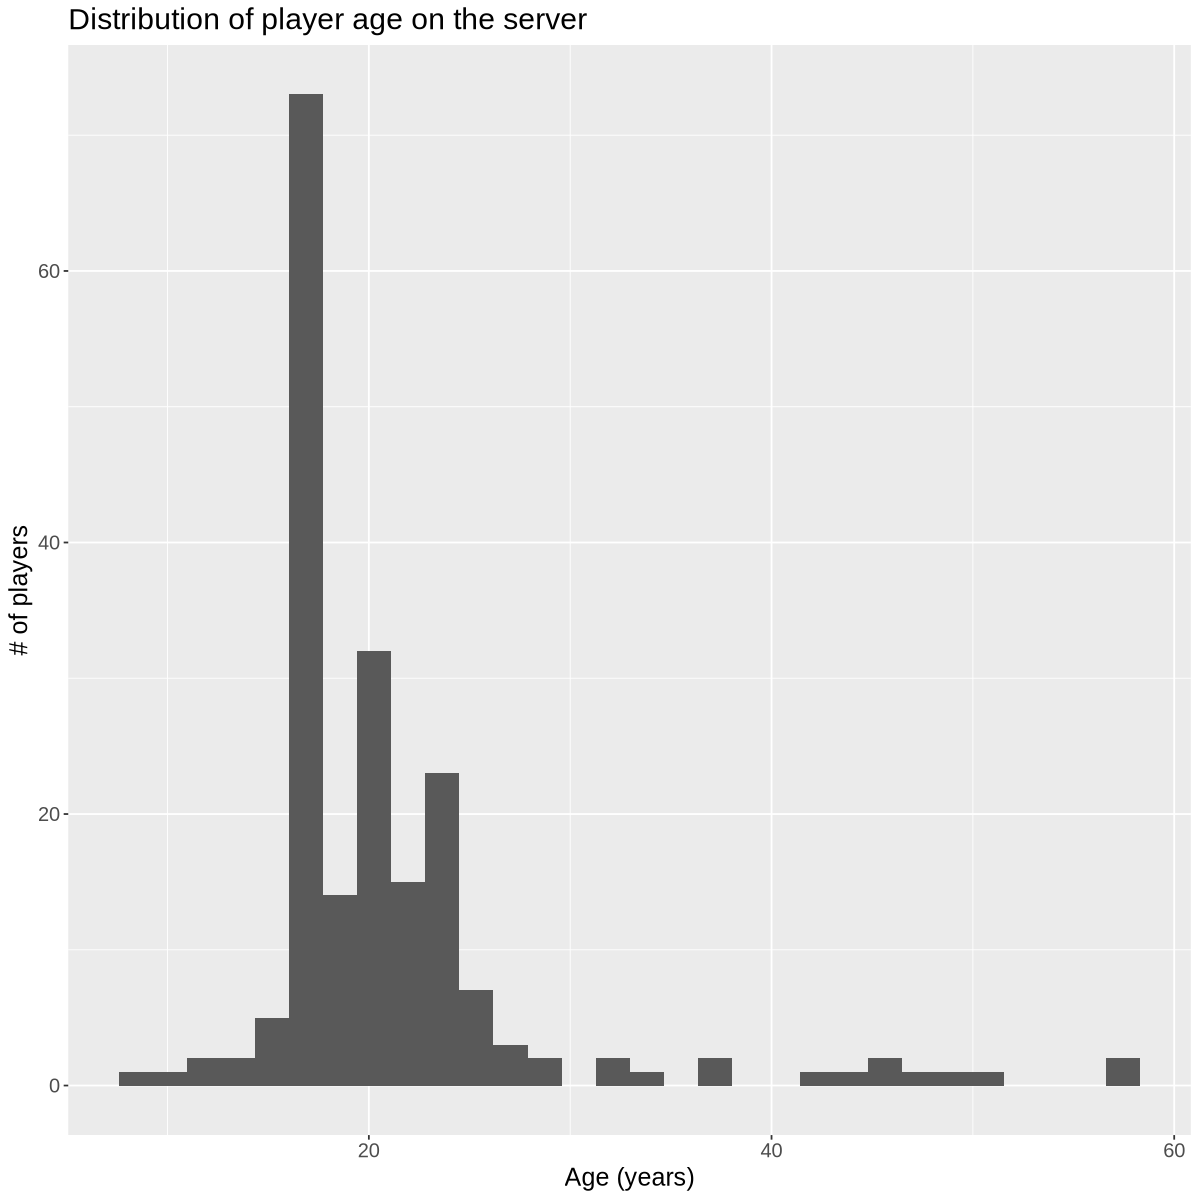

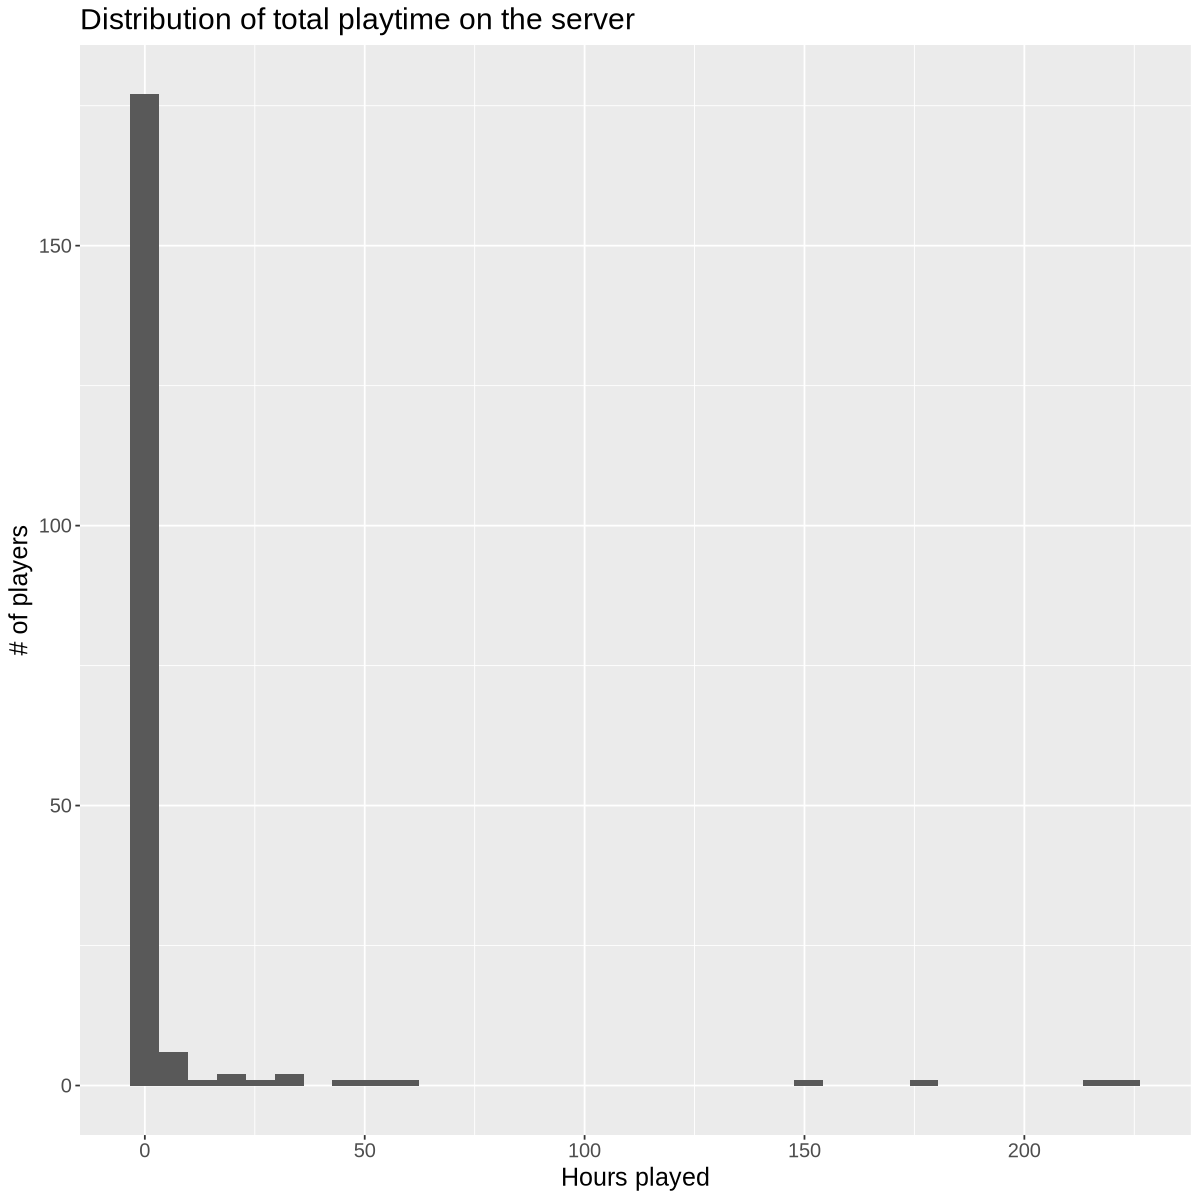

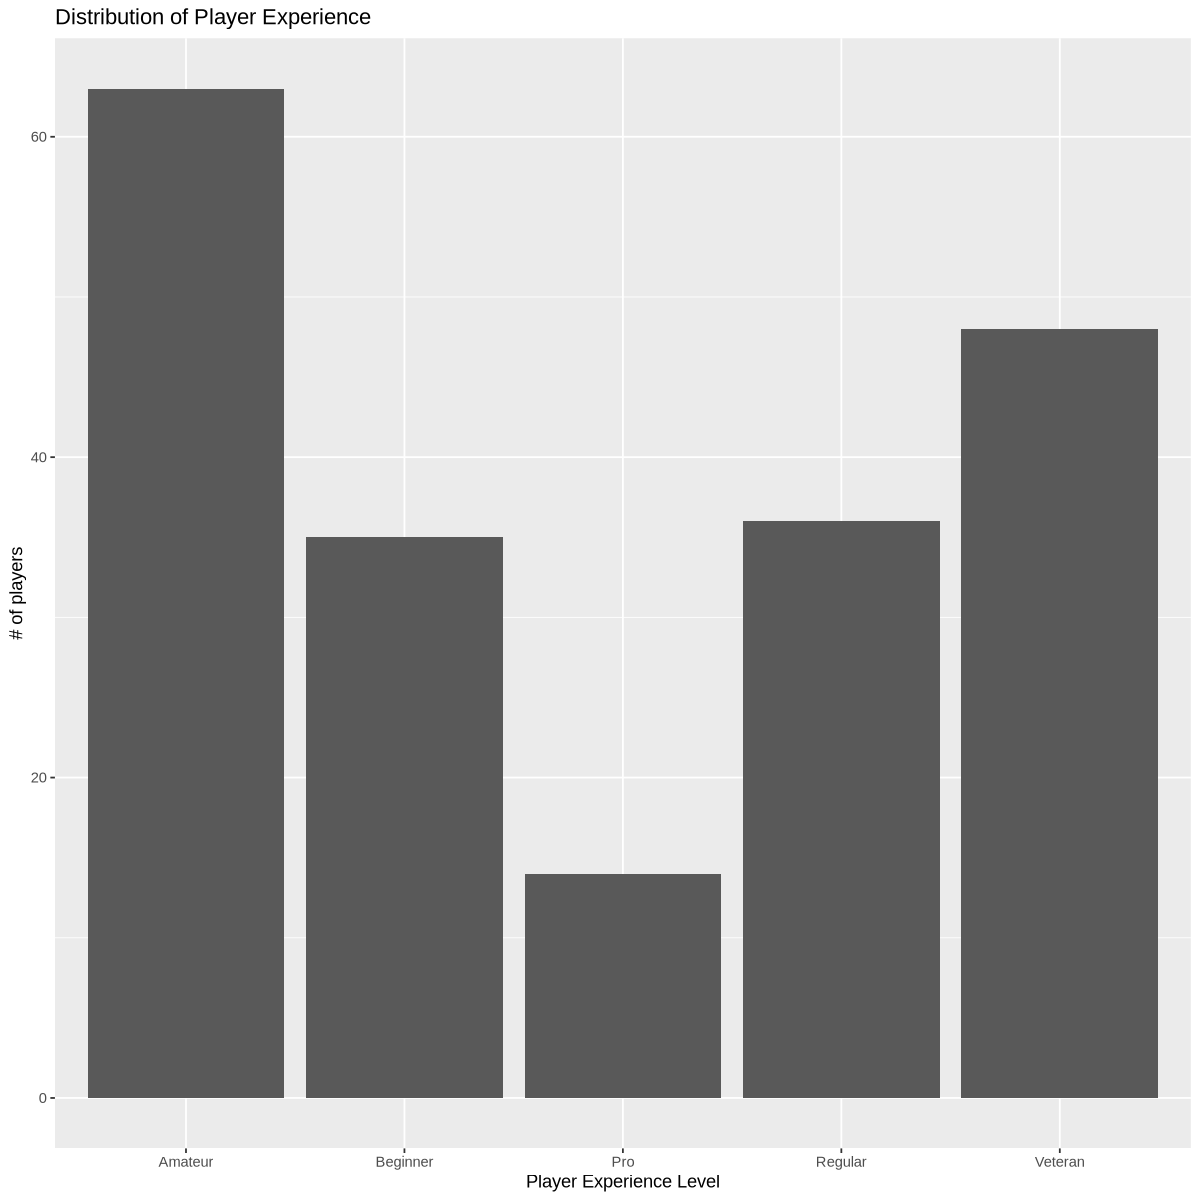

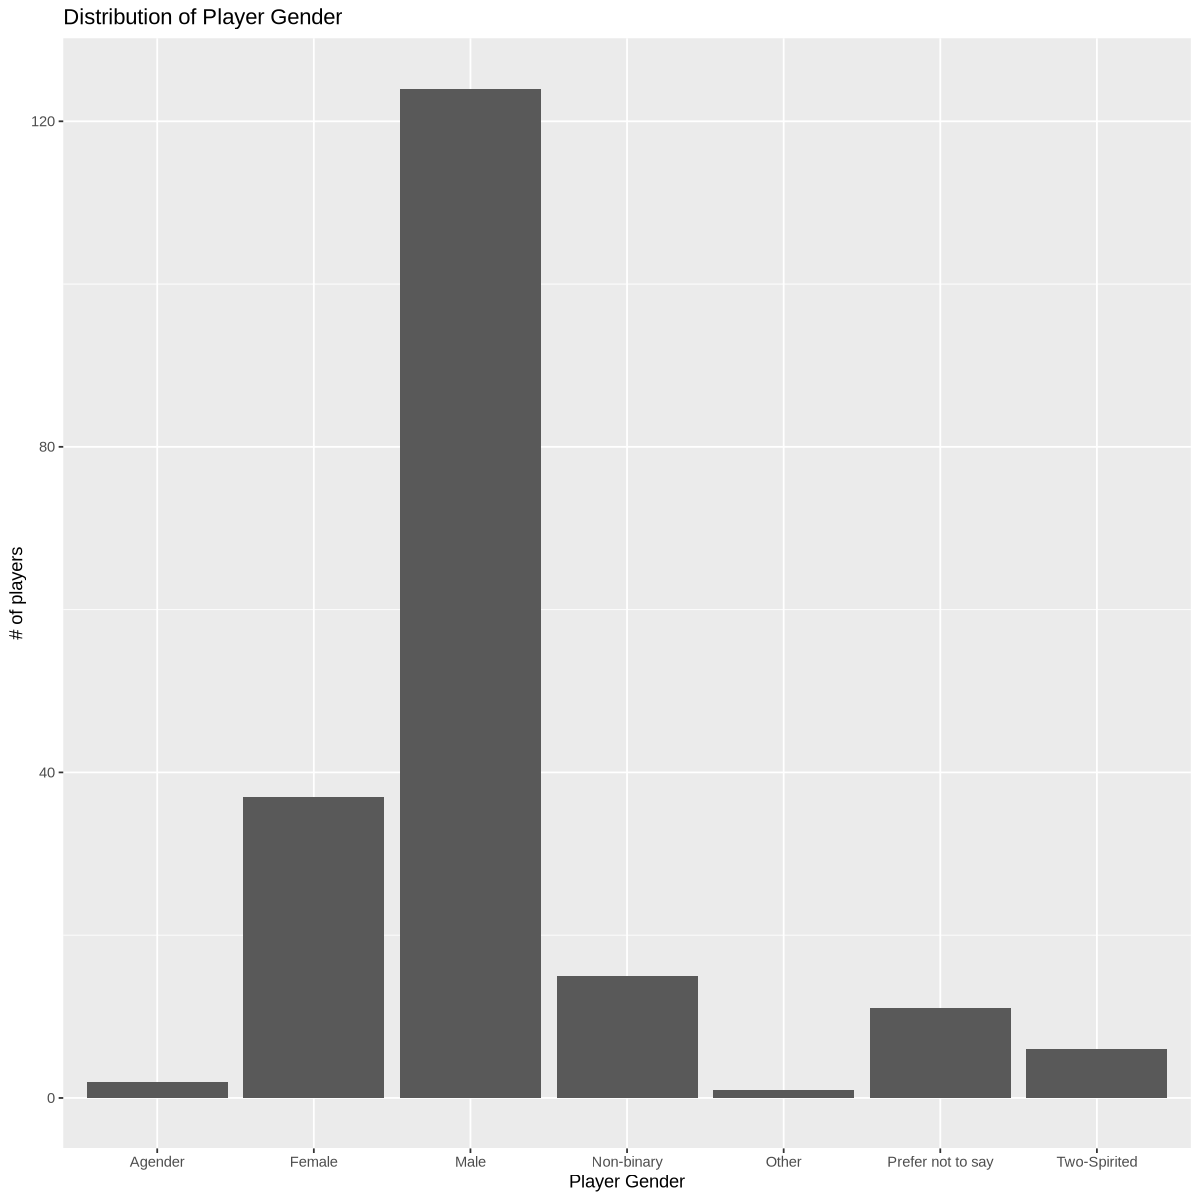

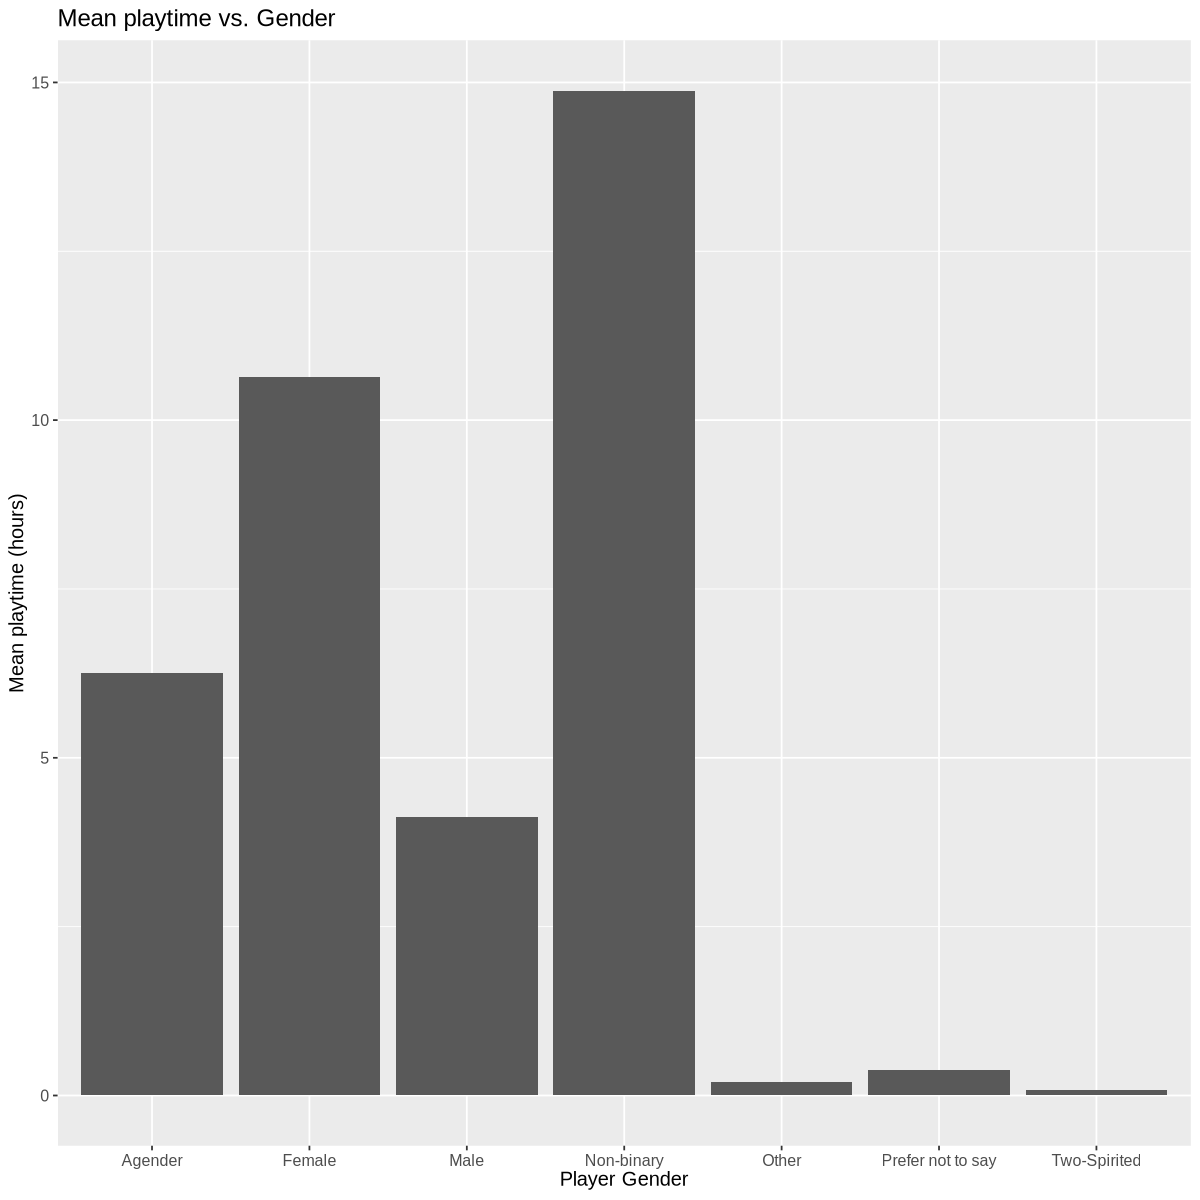

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


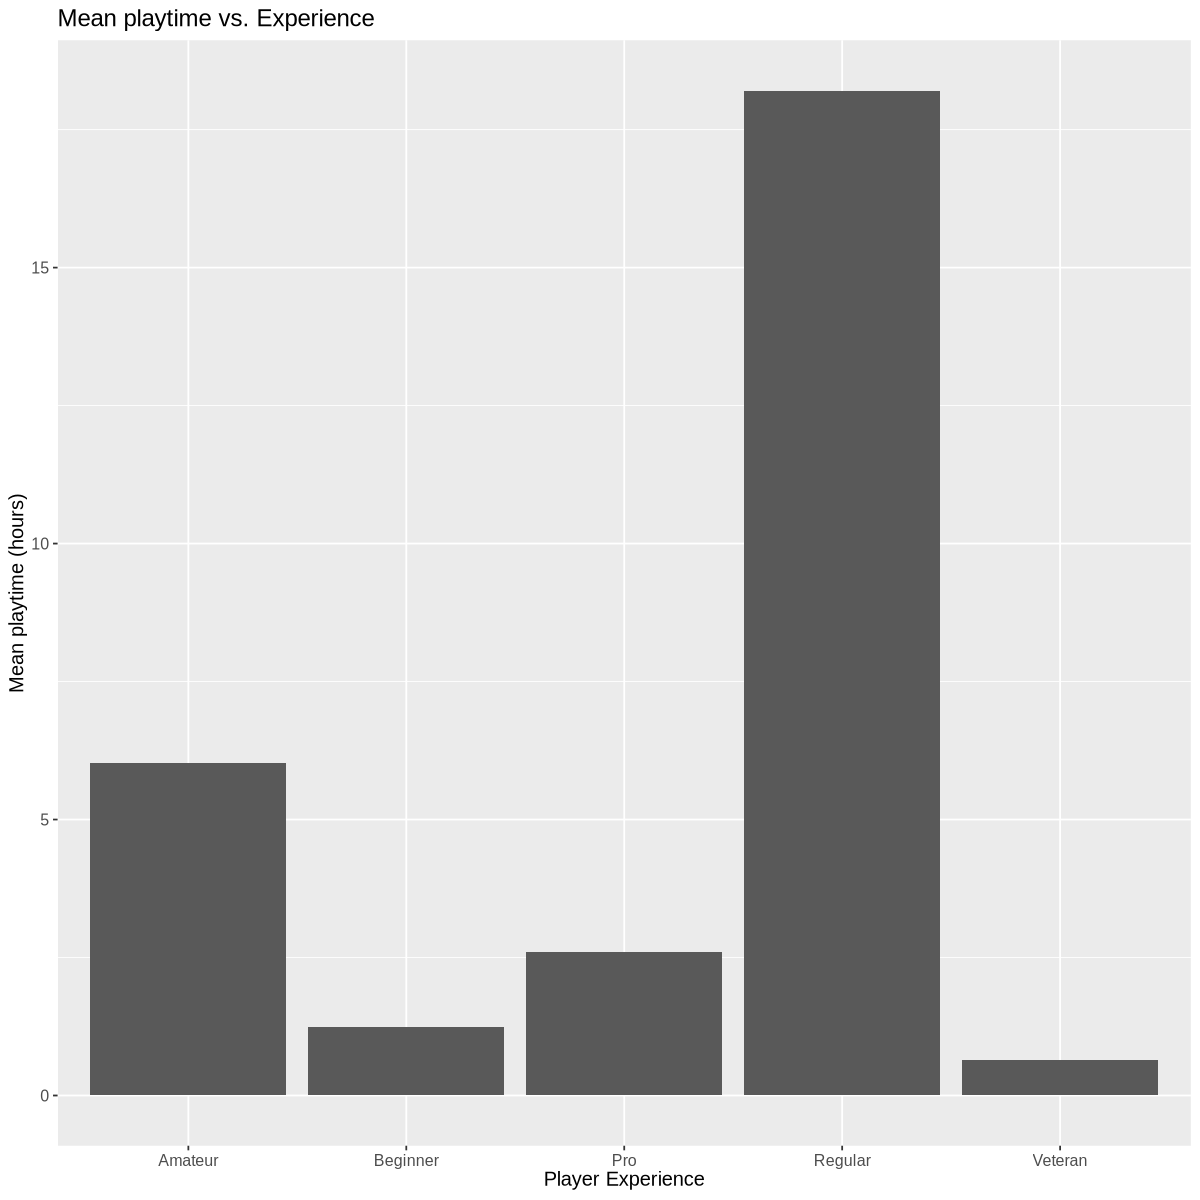

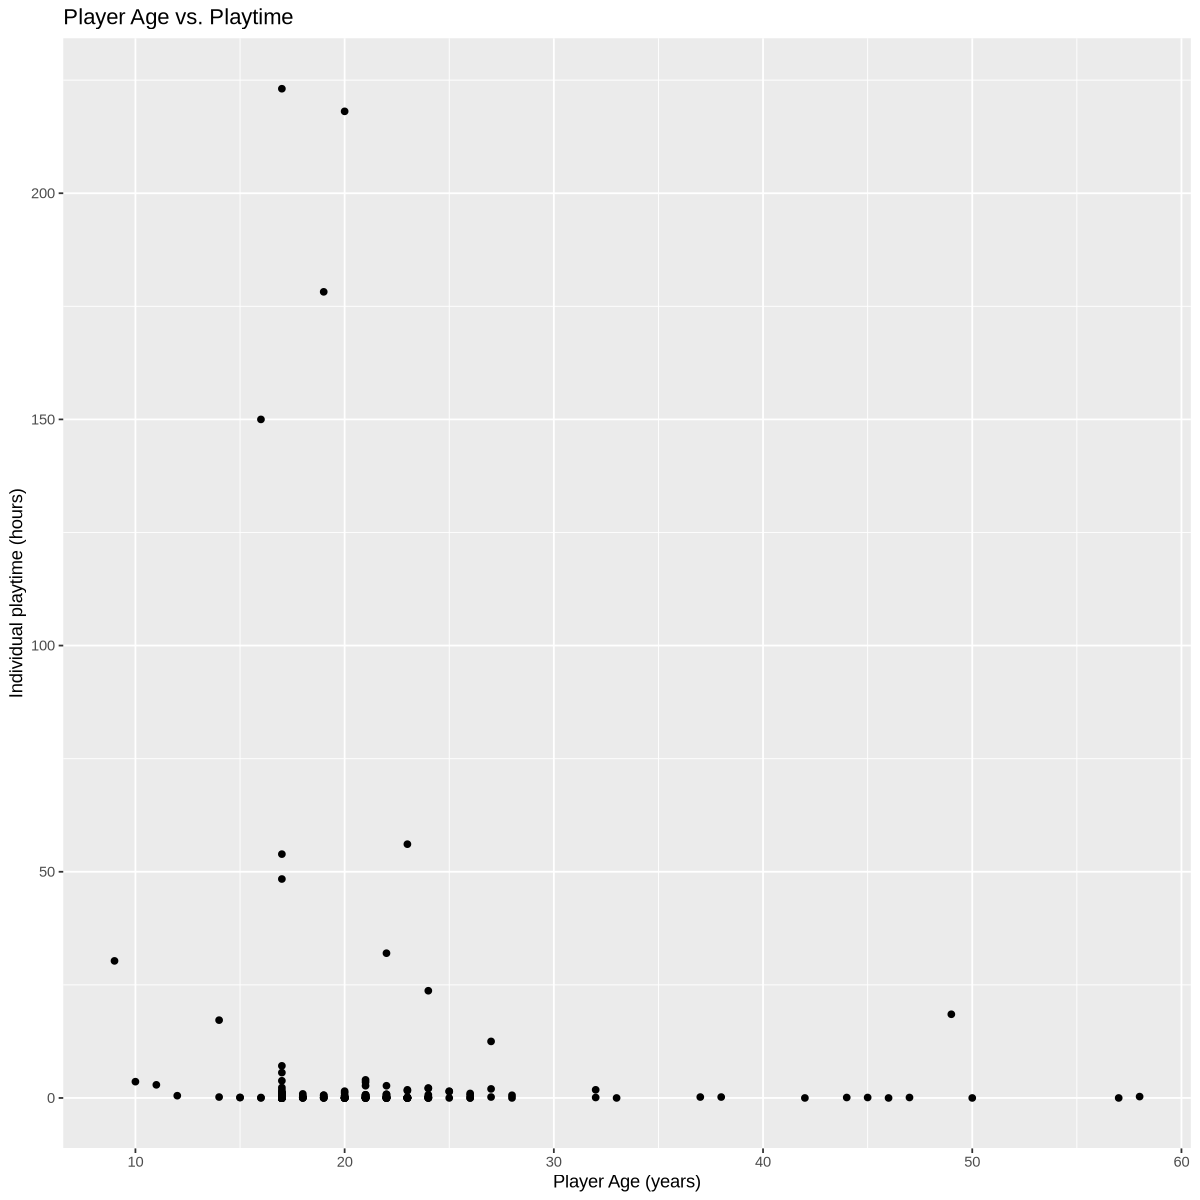

In [53]:
options(repr.plot.width = 10, repr.plot.height = 10) # set plot width and height

age_distribution <- players |>
    ggplot(aes(x = Age)) +
    geom_histogram(bins = 30) +
    labs(x = "Age (years)", y = "# of players", title = "Distribution of player age on the server") +
    theme(text = element_text(size = 15))

playtime_distribution <- players |>
    ggplot(aes(x = played_hours)) + 
    geom_histogram(bins = 35) +
    labs(x = "Hours played", y = "# of players", title = "Distribution of total playtime on the server") +
    theme(text= element_text(size= 15))

experience_distribution <- players |>
    ggplot(aes(x= experience)) +
    geom_bar() +
    labs(x = "Player Experience Level",
         y = "# of players",
         title = "Distribution of Player Experience")

gender_distribution <- players |>
    ggplot(aes(x= gender)) +
    geom_bar() +
    labs(x = "Player Gender",
         y = "# of players",
         title = "Distribution of Player Gender")

playtime_vs_gender <- players |>
    group_by(gender) |>
    summarize(mean_playtime = mean(played_hours, na.rm = TRUE))
playtime_vs_gender_plot <- playtime_vs_gender |>
    ggplot(aes(x= gender, y = mean_playtime)) +
    geom_bar(stat= "identity") +
    labs(x = "Player Gender", 
         y = "Mean playtime (hours)", 
         title = "Mean playtime vs. Gender") +
    theme(text = element_text(size = 12))

playtime_vs_experience <- players |>
    group_by(experience) |>
    summarize(mean_playtime = mean(played_hours, na.rm = TRUE))

playtime_vs_experience_plot <- playtime_vs_experience |>
    ggplot(aes(x= experience, y = mean_playtime)) +
    geom_bar(stat = "identity") +
    labs(x = "Player Experience", 
         y = "Mean playtime (hours)", 
         title = "Mean playtime vs. Experience") +
    theme(text = element_text(size = 12))

playtime_vs_age_plot <- players |>
    ggplot(aes(x = Age, y = played_hours)) +
    geom_point() +
    labs(x = "Player Age (years)", 
         y = "Individual playtime (hours)",
         title = "Player Age vs. Playtime")
    
    

age_distribution
playtime_distribution
experience_distribution
gender_distribution
playtime_vs_gender_plot
playtime_vs_experience_plot
playtime_vs_age_plot

We can extract quite a few things from the plots above:
- As established previously, the playtime distribution is very skewed, with most players having very few hours, with a select few having 50+ hours.
- Distribution of player experience among the playerbase is fairly equal (with "Amateurs" having the most representation), except that there aren't many "Pro" level players on the server.
- "Regular" experience players have the highest mean playtime on the server
- Most players on the server are around 20 years old.
- Men are the most represented gender on the server, but don't actually have the highest mean playtime. Non-binary and female players have a considerably higher mean playtime, but are less represented.
- Two-spirited, unclassified, and other gendered players have very little representation and low mean playtime.

<h2>4) Methods and Plan</h2>

The method I would use to address my question of interest would be the K-NN regression model. I think this would be the best model to use as we don't know much about how the data is distributed, and K-NN can be largely applied assumption-free. K-NN regression can use both categorical and quantitative data as its predictors. We would need to properly weigh each of the predictors so as not to have one predictor dominate the distance calculation. A weakness of this method would be having to pick a K value, as an inappropriate K value could cause either underfitting or overfitting. To compare and select the best model, we will use 5-fold cross-validation and test for a variety of K-values, then find the K-value with the highest average accuracy score to use for our model. To process the data to apply the model, I will split the dataset into a training set (70%) and a testing set (30%). Then, I can create a recipe with the response variable as played_hours and predictors as gender, experience, and age. After properly scaling and centring our predictors, we can create a K-NN model and tune for K. We would then add the recipe and model into a workflow, find the best value for K by performing 

<h2> 5) GitHub Repository</h2>

Link to my GitHub Repo: https://github.com/daisfasl/DSCI100-Individual-Project-Report